## PDF to Image


In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
# from pathlib import Path
# import random
# from collections import defaultdict
# from config.settings import cfg

# root = cfg.DATA_DIR
# sample_size = 250

# # Lấy danh sách PDF theo folder
# folder_pdfs = {}

# for folder in root.iterdir():
#     if folder.is_dir():
#         pdfs = list(folder.rglob("*.pdf"))
#         folder_pdfs[folder.name] = pdfs

# # Tổng số PDF
# total_pdfs = sum(len(v) for v in folder_pdfs.values())

# selected_files = []

# for folder_name, pdfs in folder_pdfs.items():
#     ratio = len(pdfs) / total_pdfs

#     # số lượng cần lấy theo tỷ lệ
#     n = round(sample_size * ratio)

#     # tránh lấy quá số file hiện có
#     n = min(n, len(pdfs))

#     selected_files.extend(random.sample(pdfs, n))

# print(f"Selected {len(selected_files)} files")
# selected_files

In [18]:
# from config.settings import cfg

# total = 0
# for pdf_path in selected_files:
#     saved = pdf_to_image(pdf_path, cfg.OUTPUT_DATA_DIR)
#     total += len(saved)
#     print("Total file: ", total)


In [19]:
from concurrent.futures import ThreadPoolExecutor
from fipilot.resume_extraction import ResumeExtract
from fipilot.config.settings import cfg

extractor = ResumeExtract(
    yolo_model=cfg.YOLO_MODEL,
    llm_model=cfg.LLM_MODEL,
    dpi=300,
    max_workers=cfg.MAX_WORKER,
    max_retries=cfg.MAX_RETRIES
)

pdf_files = sorted(cfg.INPUT_DATA_DIR.rglob("*.pdf"))
def process_single_pdf(pdf_path):
    try:
        saved_files = extractor.pdf_to_images(pdf_path, cfg.OUTPUT_DATA_DIR)
        print(f"Đã xử lý xong: {pdf_path.name} -> Xuất {len(saved_files)} ảnh.")
        total_file += 1
        return saved_files
    except Exception as e:
        print(f"❌ Lỗi khi xử lý file {pdf_path.name}: {str(e)}")
        return []


with ThreadPoolExecutor(max_workers=cfg.MAX_WORKER) as executor:
    results = list(executor.map(process_single_pdf, pdf_files))


## Layout Detection 

In [2]:
from concurrent.futures import ThreadPoolExecutor
from fipilot.resume_extraction import ResumeExtract
from fipilot.config.settings import cfg

extractor = ResumeExtract(
    yolo_model=cfg.YOLO_MODEL,
    llm_model=cfg.LLM_MODEL,
    dpi=150,
    max_workers=cfg.MAX_WORKER,
    max_retries=cfg.MAX_RETRIES
)

pdf_path = "/home/hoai/user/resource/fipilot/backend/test/AI_Engineer_candidate_dung-cong-anh-11835246.pdf"
saved_files = extractor.pdf_to_images(pdf_path, "/home/hoai/user/resource/fipilot/backend/test/page_image")
resume_layout = extractor.layout_detection(pdf_path)
resume_layout

{'AI_Engineer_candidate_dung-cong-anh-11835246_page_1.png': [[55.30828857421875,
   221.82666015625,
   1230.1678466796875,
   1575.6611328125],
  [341.8226318359375,
   58.911216735839844,
   965.0673217773438,
   154.68687438964844],
  [18.936017990112305,
   27.974599838256836,
   1250.1712646484375,
   182.55258178710938]],
 'AI_Engineer_candidate_dung-cong-anh-11835246_page_2.png': [[54.123043060302734,
   123.28186798095703,
   1226.47900390625,
   1591.6170654296875],
  [63.0097770690918,
   70.20960998535156,
   1219.9903564453125,
   196.52798461914062]]}

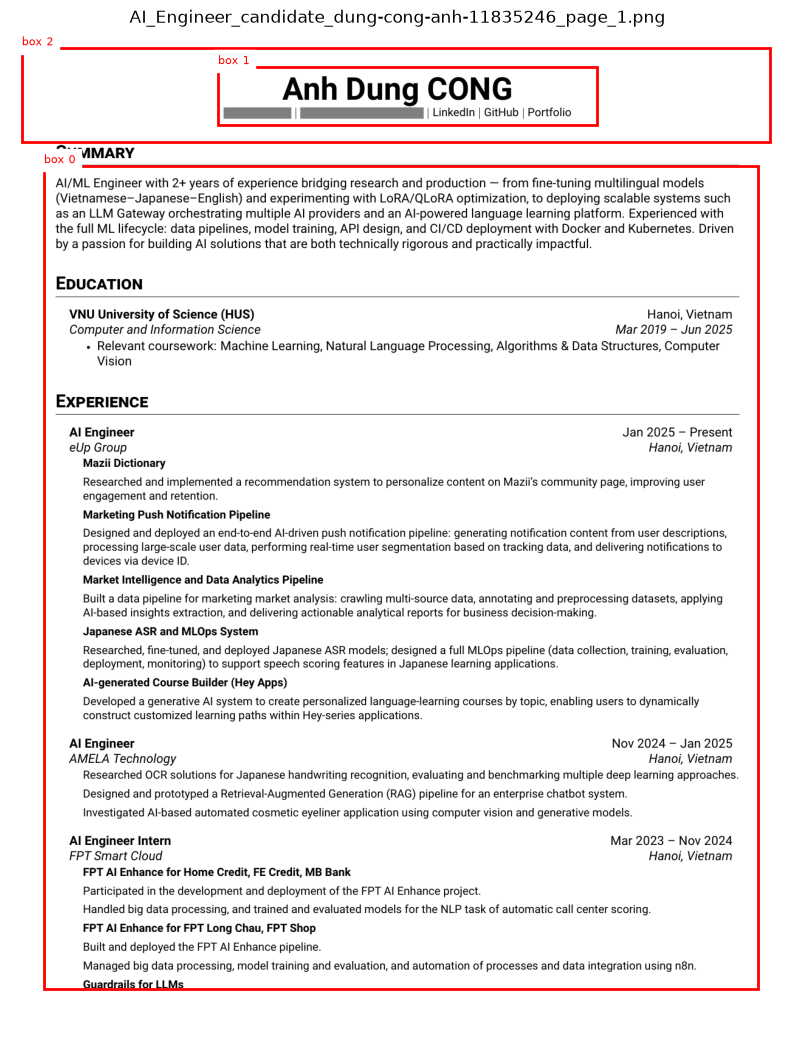

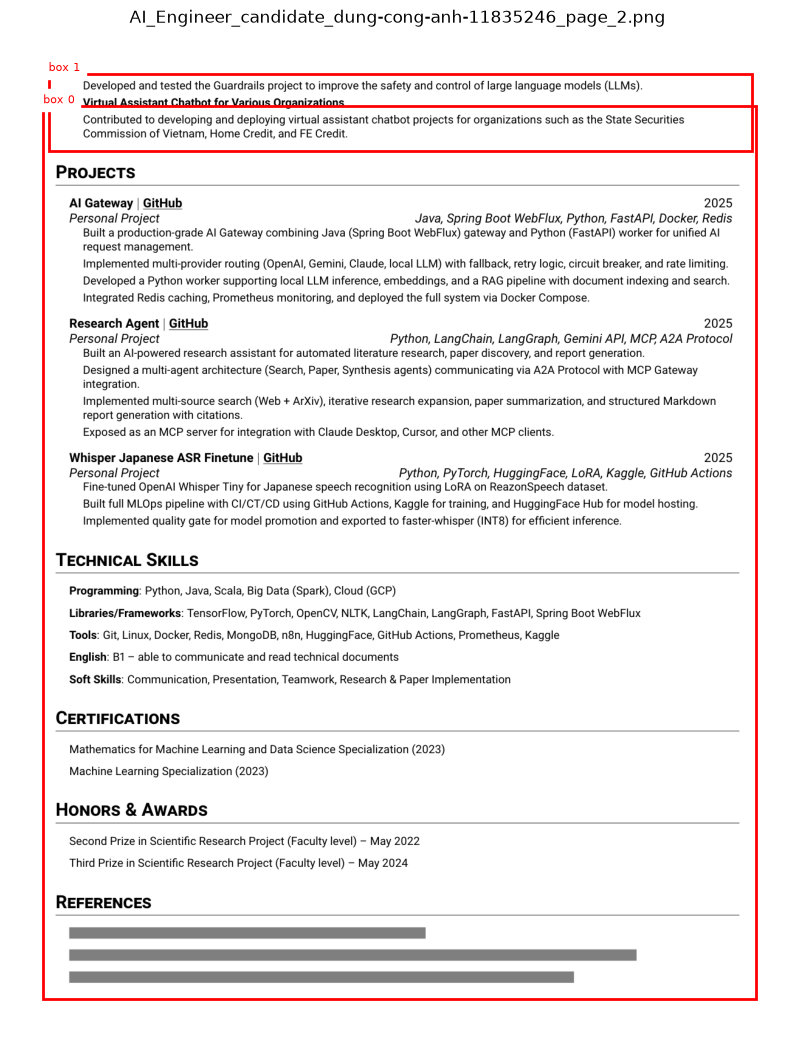

In [3]:
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from pathlib import Path

def visualize_layout(image_path, detections: dict, class_names: dict = None):
    """
    image_path: đường dẫn ảnh gốc
    detections: output từ layout_detection(), key là image_name
    class_names: {0: 'header', 1: 'education', ...} — optional
    """
    image_path = Path(image_path)
    xyxy = detections.get(image_path.name)
    
    if xyxy is None:
        print(f"Không tìm thấy detection cho {image_path.name}")
        return

    img = cv2.imread(str(image_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1, figsize=(10, 15))
    ax.imshow(img_rgb)

    # xyxy có thể là tensor hoặc numpy
    if hasattr(xyxy, 'cpu'):
        boxes = xyxy.cpu().numpy()
    else:
        boxes = xyxy

    for i, box in enumerate(boxes):
        x1, y1, x2, y2 = box[:4]
        w, h = x2 - x1, y2 - y1

        rect = patches.Rectangle(
            (x1, y1), w, h,
            linewidth=2, edgecolor='red', facecolor='none'
        )
        ax.add_patch(rect)

        label = class_names[i] if class_names else f"box {i}"
        ax.text(x1, y1 - 5, label, color='red', fontsize=8,
                backgroundcolor='white')

    plt.axis("off")
    plt.title(image_path.name)
    plt.show()

for image_path in saved_files:
    visualize_layout(image_path, resume_layout)

In [4]:
all_boxes = extractor.remove_duplicate_boxes(resume_layout)
all_boxes


{'AI_Engineer_candidate_dung-cong-anh-11835246_page_1.png': [[55.30828857421875,
   221.82666015625,
   1230.1678466796875,
   1575.6611328125],
  [18.936017990112305,
   27.974599838256836,
   1250.1712646484375,
   182.55258178710938]],
 'AI_Engineer_candidate_dung-cong-anh-11835246_page_2.png': [[54.123043060302734,
   123.28186798095703,
   1226.47900390625,
   1591.6170654296875],
  [63.0097770690918,
   70.20960998535156,
   1219.9903564453125,
   196.52798461914062]]}

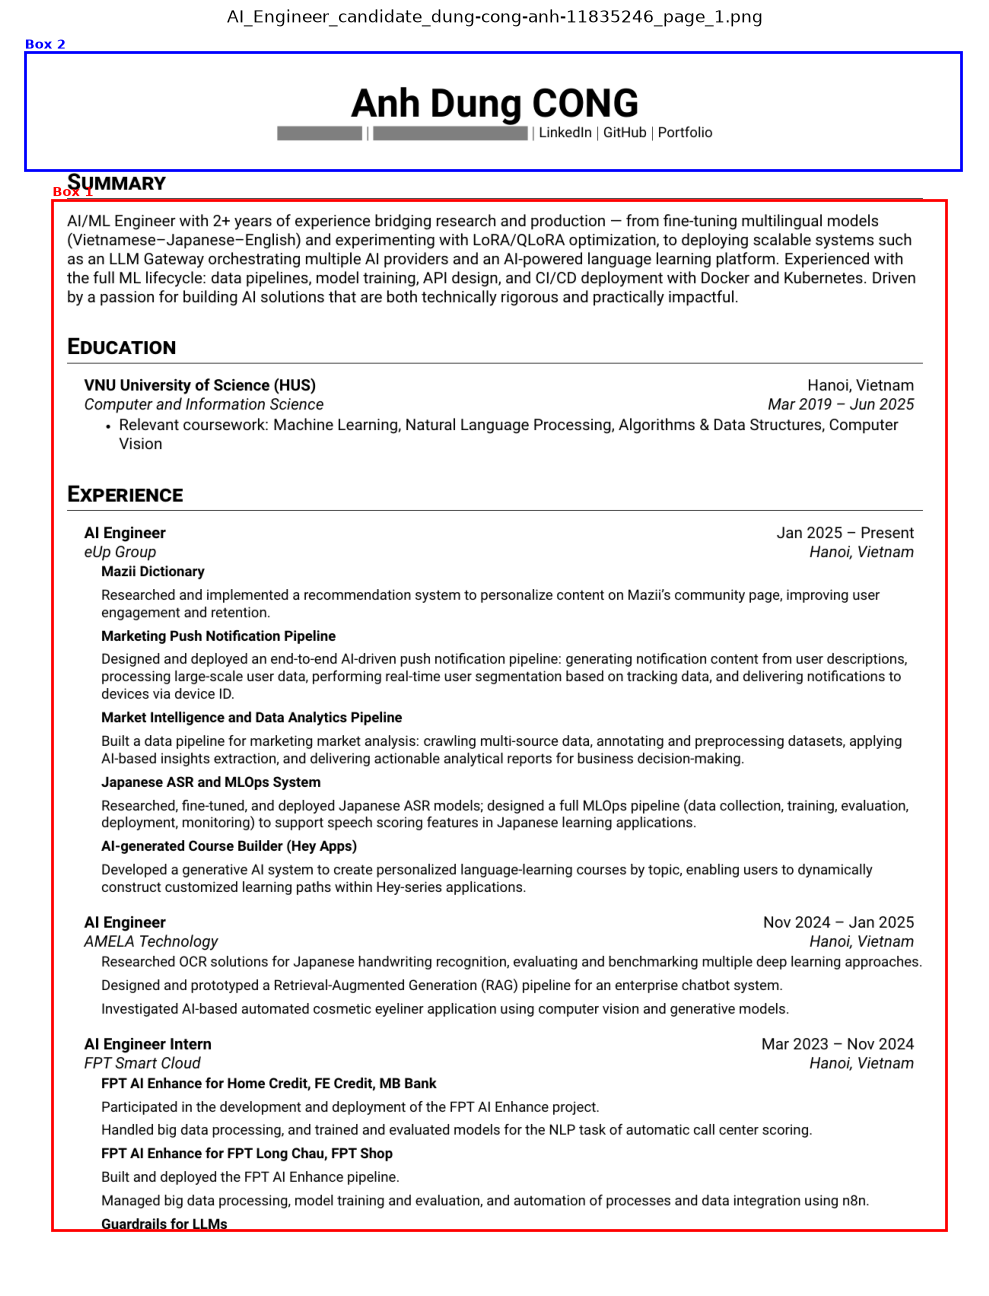

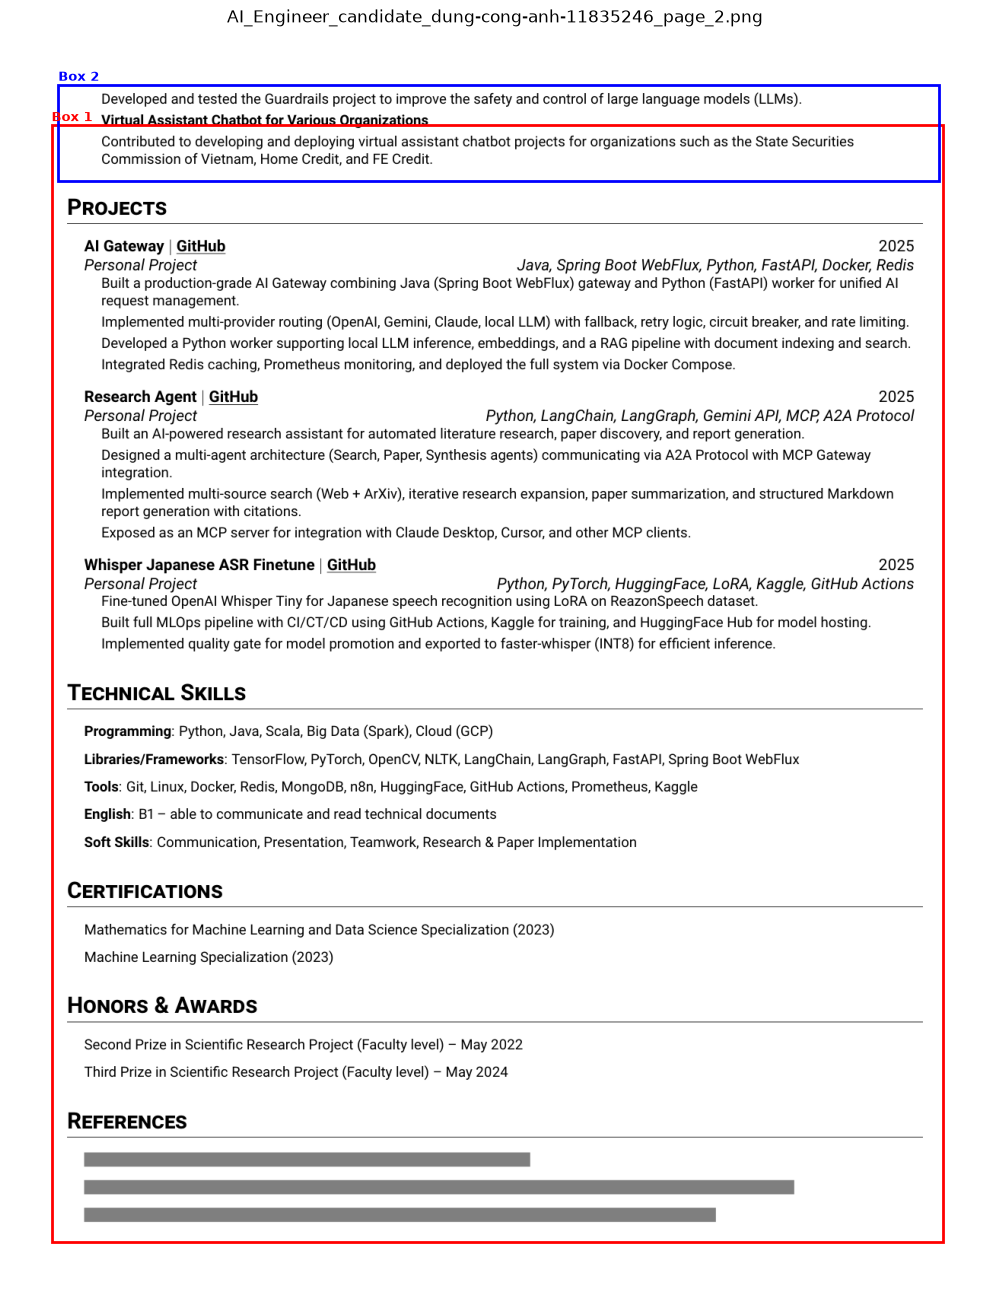

In [5]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.image as mpimg
from pathlib import Path

colors = ['red', 'blue', 'green', 'orange', 'purple', 'cyan']

image_dir = {path.name: path for path in saved_files}

for image_name, boxes in all_boxes.items():

    img = mpimg.imread(image_dir[image_name])

    fig, ax = plt.subplots(figsize=(10, 15))
    ax.imshow(img)

    for i, box in enumerate(boxes):

        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            edgecolor=colors[i % len(colors)],
            facecolor='none'
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            max(0, y1 - 5),
            f"Box {i + 1}",
            color=colors[i % len(colors)],
            fontsize=9,
            fontweight="bold"
        )

    ax.set_title(image_name)
    ax.axis("off")
    plt.tight_layout()
    plt.show()

## Sorting and Map metadata

In [6]:
inter_boxes = extractor.inter_segment_sorting(all_boxes)
inter_boxes

{'AI_Engineer_candidate_dung-cong-anh-11835246_page_1.png': [[18.936017990112305,
   27.974599838256836,
   1250.1712646484375,
   182.55258178710938],
  [55.30828857421875, 221.82666015625, 1230.1678466796875, 1575.6611328125]],
 'AI_Engineer_candidate_dung-cong-anh-11835246_page_2.png': [[63.0097770690918,
   70.20960998535156,
   1219.9903564453125,
   196.52798461914062],
  [54.123043060302734,
   123.28186798095703,
   1226.47900390625,
   1591.6170654296875]]}

In [7]:
resume = extractor.pair_resume(pdf_path)
resume

{'AI_Engineer_candidate_dung-cong-anh-11835246_page_1.png': [{'bbox': (448.1124877929688,
    61.78107659022014,
    826.8903732299806,
    113.42086791992189),
   'text': 'Anh Dung CONG'},
  {'bbox': (467.5603866577149,
    125.59227148691814,
    472.9028701782227,
    144.27227973937988),
   'text': '|'},
  {'bbox': (685.2645874023438,
    125.59227148691814,
    923.5925674438478,
    144.5480028788249),
   'text': '| LinkedIn | GitHub | Portfolio'},
  {'bbox': (74.99993642171225,
    179.08082008361816,
    205.22160530090335,
    208.96873474121097),
   'text': 'SUMMARY'},
  {'bbox': (75.0, 241.15176200866702, 1142.1187082926433, 261.90718015035),
   'text': 'AI/ML Engineer with 2+ years of experience bridging research and production — from ne-tuning multilingual models'},
  {'bbox': (75.0, 266.0580476125082, 1185.6011708577475, 286.81348164876306),
   'text': '(Vietnamese–Japanese–English) and experimenting with LoRA/QLoRA optimization, to deploying scalable systems such'},
  {'

In [10]:
intra_boxes = extractor.intra_segment_sorting(inter_boxes, resume)
intra_boxes

[{'image': 'AI_Engineer_candidate_dung-cong-anh-11835246_page_1.png',
  'bbox': [18.936017990112305,
   27.974599838256836,
   1250.1712646484375,
   182.55258178710938],
  'contained_blocks': [{'bbox': (448.1124877929688,
     61.78107659022014,
     826.8903732299806,
     113.42086791992189),
    'text': 'Anh Dung CONG'},
   {'bbox': (467.5603866577149,
     125.59227148691814,
     472.9028701782227,
     144.27227973937988),
    'text': '|'},
   {'bbox': (685.2645874023438,
     125.59227148691814,
     923.5925674438478,
     144.5480028788249),
    'text': '| LinkedIn | GitHub | Portfolio'}]},
 {'image': 'AI_Engineer_candidate_dung-cong-anh-11835246_page_1.png',
  'bbox': [55.30828857421875,
   221.82666015625,
   1230.1678466796875,
   1575.6611328125],
  'contained_blocks': [{'bbox': (75.0,
     241.15176200866702,
     1142.1187082926433,
     261.90718015035),
    'text': 'AI/ML Engineer with 2+ years of experience bridging research and production — from ne-tuning multilingu

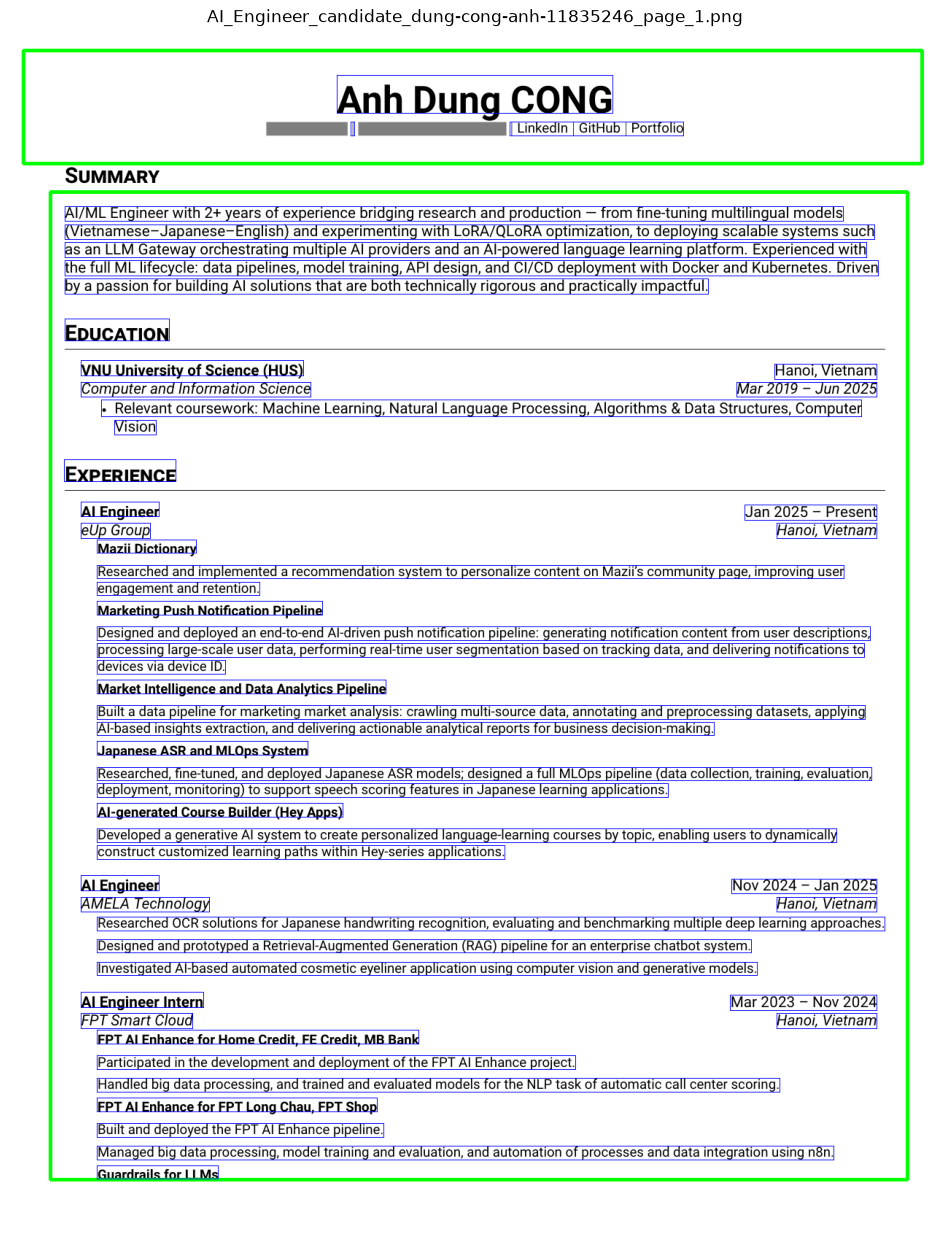

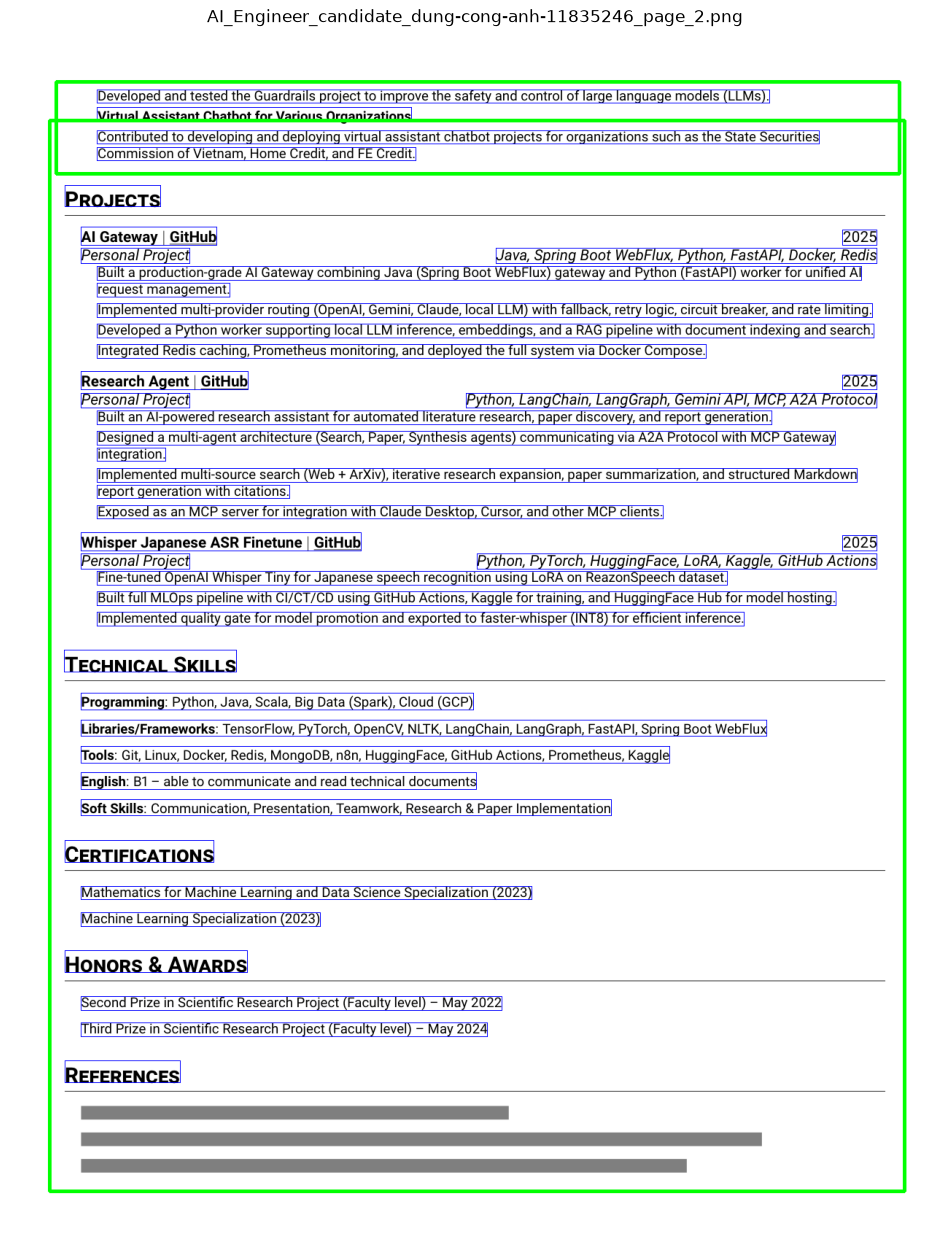

In [11]:
from collections import defaultdict
import cv2
import matplotlib.pyplot as plt

image_lookup = {path.name: path for path in saved_files}

grouped = defaultdict(list)
for region in intra_boxes:
    grouped[region["image"]].append(region)

for image_name, regions in grouped.items():
    img = cv2.imread(str(image_lookup[image_name]))
    
    for region in regions:
        # YOLO bbox (xanh lá)
        x1, y1, x2, y2 = map(int, region["bbox"])
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
        
        # Contained blocks (xanh dương)
        for block in region["contained_blocks"]:
            bx1, by1, bx2, by2 = map(int, block["bbox"])
            cv2.rectangle(img, (bx1, by1), (bx2, by2), (255, 0, 0), 1)
    
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(12, 16))
    plt.title(image_name)
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()

In [12]:
linearized_text = extractor.linearize_layout_regions(intra_boxes)
linearized_text

'[0]: Anh Dung CONG [1]: | [2]: | LinkedIn | GitHub | Portfolio [3]: AI/ML Engineer with 2+ years of experience bridging research and production — from ne-tuning multilingual models [4]: (Vietnamese–Japanese–English) and experimenting with LoRA/QLoRA optimization, to deploying scalable systems such [5]: as an LLM Gateway orchestrating multiple AI providers and an AI-powered language learning platform. Experienced with [6]: the full ML lifecycle: data pipelines, model training, API design, and CI/CD deployment with Docker and Kubernetes. Driven [7]: by a passion for building AI solutions that are both technically rigorous and practically impactful. [8]: EDUCATION [9]: VNU University of Science (HUS) [10]: Hanoi, Vietnam [11]: Computer and Information Science [12]: Mar 2019 – Jun 2025 [13]: - Relevant coursework: Machine Learning, Natural Language Processing, Algorithms & Data Structures, Computer [14]: Vision [15]: EXPERIENCE [16]: AI Engineer [17]: Jan 2025 – Present [18]: eUp Group [1